# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Load Datasets

In [2]:
trips = pd.read_csv(r"F:\ubar-trip-analysis-logistics\data\raw_data\Uber Trip Details.csv")
locations = pd.read_csv(r"F:\ubar-trip-analysis-logistics\data\raw_data\Location Table.csv")

# Inspect

In [3]:
trips.head(5)

,Trip ID,Pickup Time,Drop Off Time,passenger_count,trip_distance,PULocationID,DOLocationID,fare_amount,Surge Fee,Vehicle,Payment_type
0,1,6/1/2024 0:42,6/1/2024 1:04,1,5.60,79,226,19.5,2.0,UberX,Uber Pay
1,2,6/1/2024 0:06,6/1/2024 0:13,1,1.72,142,186,8.0,0.0,Uber Black,Cash
2,3,6/1/2024 0:08,6/1/2024 0:21,1,3.41,229,238,13.0,0.0,Uber Black,Cash
3,4,6/1/2024 0:28,6/1/2024 0:37,1,1.81,188,35,9.0,0.0,UberX,Cash
4,5,6/1/2024 0:38,6/1/2024 0:45,1,1.89,100,137,8.0,0.0,Uber Black,Cash


In [4]:
trips.shape

(103728, 11)

In [5]:
trips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103728 entries, 0 to 103727
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Trip ID          103728 non-null  int64  
 1   Pickup Time      103728 non-null  object 
 2   Drop Off Time    103728 non-null  object 
 3   passenger_count  103728 non-null  int64  
 4   trip_distance    103728 non-null  float64
 5   PULocationID     103728 non-null  int64  
 6   DOLocationID     103728 non-null  int64  
 7   fare_amount      103728 non-null  float64
 8   Surge Fee        103728 non-null  float64
 9   Vehicle          103728 non-null  object 
 10  Payment_type     103728 non-null  object 
dtypes: float64(3), int64(4), object(4)
memory usage: 8.7+ MB


In [6]:
locations.head(5)

,LocationID,Location,City
0,1,Newark Airport,"Newark, New Jersey"
1,2,Jamaica Bay,Queens
2,3,Allerton/Pelham Gardens,The Bronx
3,4,Alphabet City,Manhattan
4,5,Arden Heights,Staten Island


In [7]:
locations.shape

(265, 3)

In [8]:
locations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   LocationID  265 non-null    int64 
 1   Location    264 non-null    object
 2   City        263 non-null    object
dtypes: int64(1), object(2)
memory usage: 6.3+ KB


# ETL: Cleaning & Transformation

# Clean column names

In [9]:
trips.columns = trips.columns.str.strip().str.lower().str.replace(" ", "_")

# Convert datetime

In [10]:
trips['pickup_time'] = pd.to_datetime(trips['pickup_time'])
trips['drop_off_time'] = pd.to_datetime(trips['drop_off_time'])

# Feature engineering

In [11]:
trips['trip_duration_minutes'] = (trips['drop_off_time'] - trips['pickup_time']).dt.total_seconds()/60
trips['total_fare'] = trips['fare_amount'] + trips['surge_fee']
trips['hour'] = trips['pickup_time'].dt.hour
trips['day'] = trips['pickup_time'].dt.day
trips['month'] = trips['pickup_time'].dt.month
trips['weekday'] = trips['pickup_time'].dt.day_name()

# Clean location table

In [12]:
locations.columns = locations.columns.str.strip().str.lower().str.replace(" ", "_")

# Merge pickup & dropoff locations

In [13]:
trips = trips.merge(locations, left_on="pulocationid", right_on="locationid", how="left", suffixes=("", "_pickup"))
trips = trips.merge(locations, left_on="dolocationid", right_on="locationid", how="left", suffixes=("", "_dropoff"))

In [14]:
trips.head(5)

,trip_id,pickup_time,drop_off_time,passenger_count,trip_distance,pulocationid,dolocationid,fare_amount,surge_fee,vehicle,...,hour,day,month,weekday,locationid,location,city,locationid_dropoff,location_dropoff,city_dropoff
0,1,2024-06-01 00:42:00,2024-06-01 01:04:00,1,5.60,79,226,19.5,2.0,UberX,...,0,1,6,Saturday,79,East Village,Brooklyn,226,Sunnyside,Queens
1,2,2024-06-01 00:06:00,2024-06-01 00:13:00,1,1.72,142,186,8.0,0.0,Uber Black,...,0,1,6,Saturday,142,Lincoln Square East,Manhattan,186,Penn Station/Madison Sq West,Manhattan
2,3,2024-06-01 00:08:00,2024-06-01 00:21:00,1,3.41,229,238,13.0,0.0,Uber Black,...,0,1,6,Saturday,229,Sutton Place/Turtle Bay North,Manhattan,238,Upper West Side North,Manhattan
3,4,2024-06-01 00:28:00,2024-06-01 00:37:00,1,1.81,188,35,9.0,0.0,UberX,...,0,1,6,Saturday,188,Prospect-Lefferts Gardens,Brooklyn,35,Brownsville,Brooklyn
4,5,2024-06-01 00:38:00,2024-06-01 00:45:00,1,1.89,100,137,8.0,0.0,Uber Black,...,0,1,6,Saturday,100,Garment District,Queens,137,Kips Bay,Manhattan


# EDA: Exploratory Data Analysis

# Dataset overview

In [15]:
print("Missing values:\n", trips.isnull().sum())
print("Summary statistics:\n", trips.describe(include="all"))

Missing values:
 trip_id                    0
pickup_time                0
drop_off_time              0
passenger_count            0
trip_distance              0
pulocationid               0
dolocationid               0
fare_amount                0
surge_fee                  0
vehicle                    0
payment_type               0
trip_duration_minutes      0
total_fare                 0
hour                       0
day                        0
month                      0
weekday                    0
locationid                 0
location                  26
city                     926
locationid_dropoff         0
location_dropoff         155
city_dropoff             684
dtype: int64
Summary statistics:
               trip_id                    pickup_time  \
count   103728.000000                         103728   
unique            NaN                            NaN   
top               NaN                            NaN   
freq              NaN                            NaN   
me

# Missing Data Heatmap

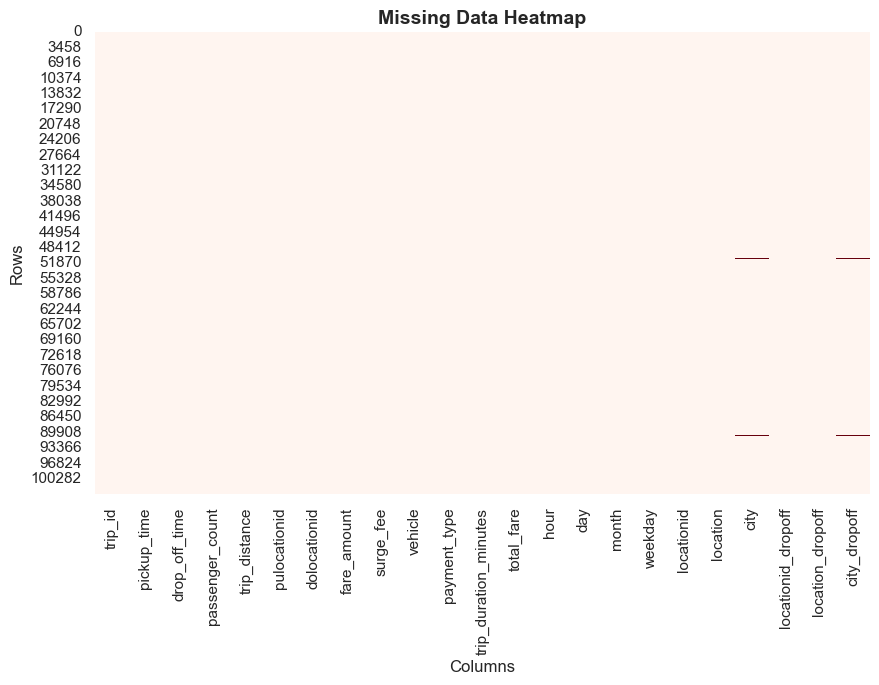

In [17]:
plt.figure(figsize=(10,6))
sns.heatmap(trips.isnull(), cbar=False, cmap='Reds')
plt.title("Missing Data Heatmap", fontsize=14, fontweight='bold')
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

# Trips by Hour

C:\Users\User\AppData\Local\Temp\ipykernel_436\2357109566.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='hour', data=trips, palette="viridis")


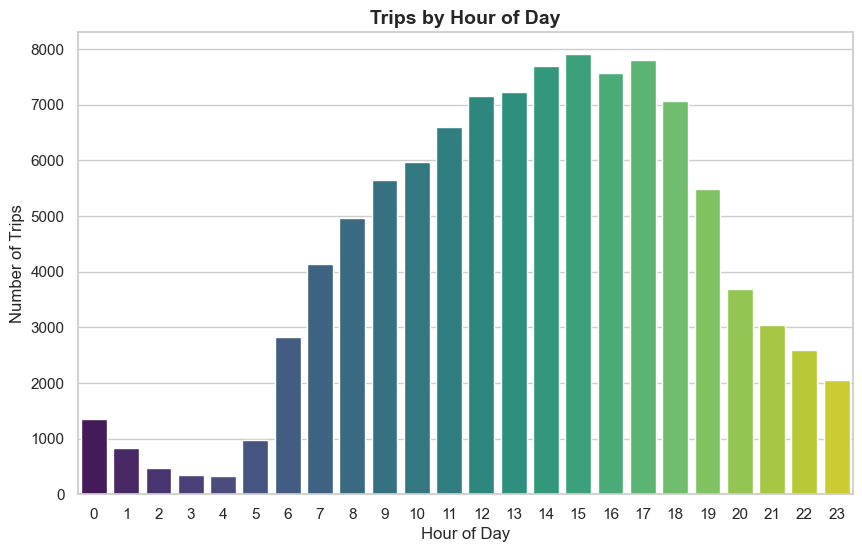

In [18]:
plt.figure(figsize=(10,6))
sns.countplot(x='hour', data=trips, palette="viridis")
plt.title("Trips by Hour of Day", fontsize=14, fontweight='bold')
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.xticks(rotation=0)
plt.show()

# Revenue by Vehicle Type

C:\Users\User\AppData\Local\Temp\ipykernel_436\2304027568.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=revenue_by_vehicle.index, y=revenue_by_vehicle.values, palette="Blues_d")


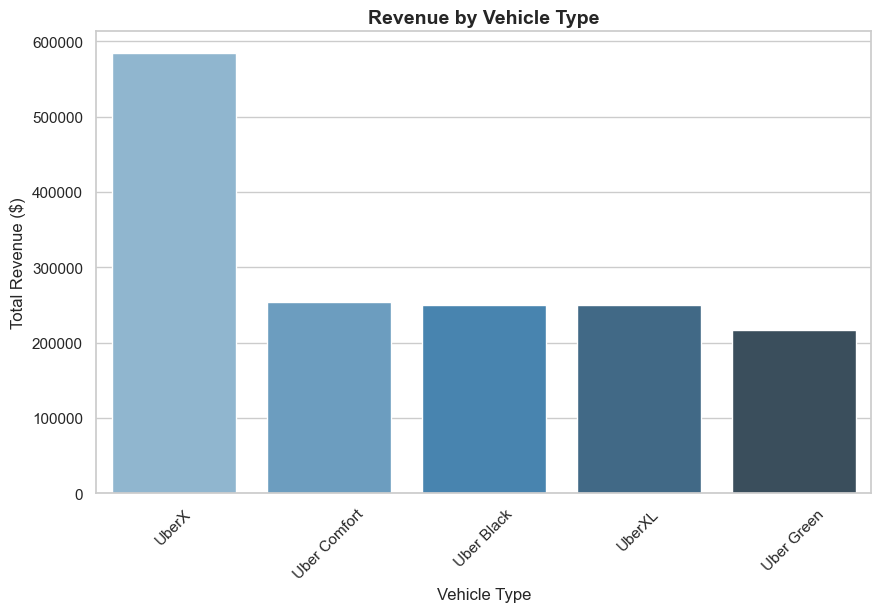

In [19]:
plt.figure(figsize=(10,6))
revenue_by_vehicle = trips.groupby('vehicle')['total_fare'].sum().sort_values(ascending=False)
sns.barplot(x=revenue_by_vehicle.index, y=revenue_by_vehicle.values, palette="Blues_d")
plt.title("Revenue by Vehicle Type", fontsize=14, fontweight='bold')
plt.xlabel("Vehicle Type")
plt.ylabel("Total Revenue ($)")
plt.xticks(rotation=45)
plt.show()

# Payment Type Distribution

C:\Users\User\AppData\Local\Temp\ipykernel_436\706816502.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='payment_type', data=trips, palette="Set2", order=trips['payment_type'].value_counts().index)


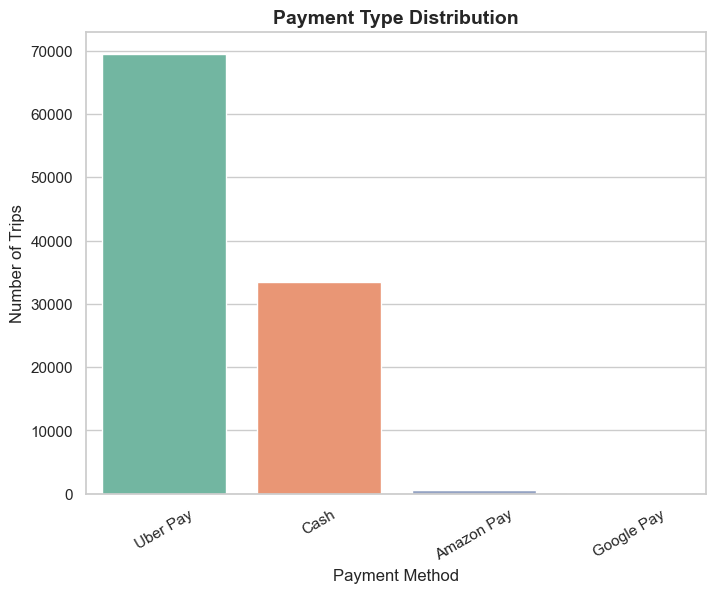

In [20]:
plt.figure(figsize=(8,6))
sns.countplot(x='payment_type', data=trips, palette="Set2", order=trips['payment_type'].value_counts().index)
plt.title("Payment Type Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Payment Method")
plt.ylabel("Number of Trips")
plt.xticks(rotation=30)
plt.show()

# Average Trip Duration by Pickup City

C:\Users\User\AppData\Local\Temp\ipykernel_436\2749796694.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_duration_city.index, y=avg_duration_city.values, palette="OrRd")


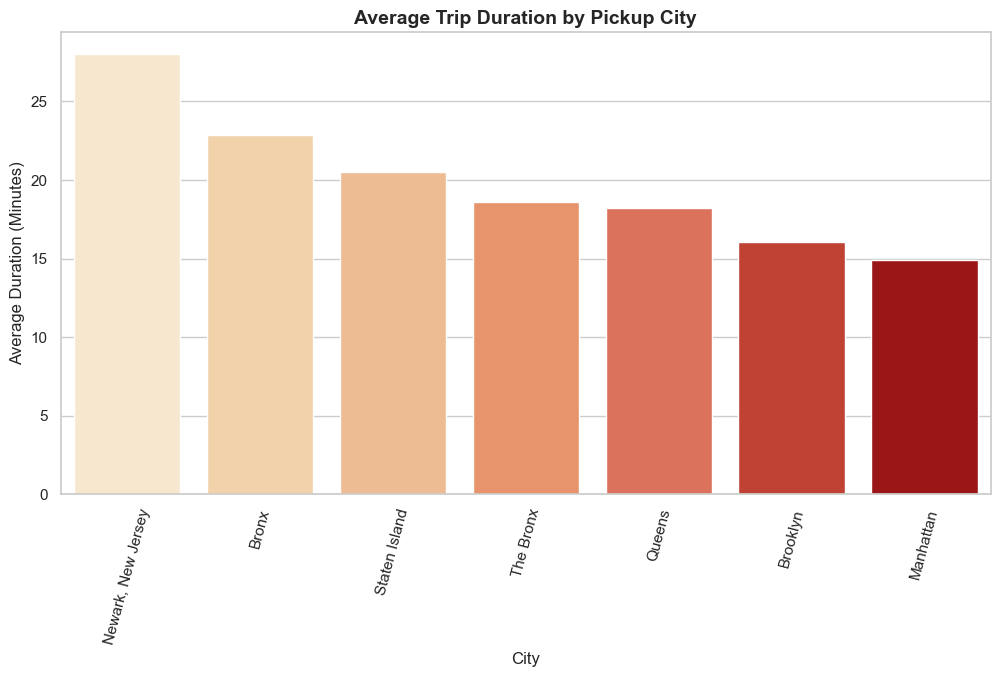

In [21]:
plt.figure(figsize=(12,6))
avg_duration_city = trips.groupby('city')['trip_duration_minutes'].mean().sort_values(ascending=False)
sns.barplot(x=avg_duration_city.index, y=avg_duration_city.values, palette="OrRd")
plt.title("Average Trip Duration by Pickup City", fontsize=14, fontweight='bold')
plt.xlabel("City")
plt.ylabel("Average Duration (Minutes)")
plt.xticks(rotation=75)
plt.show()

# Surge Fee Contribution

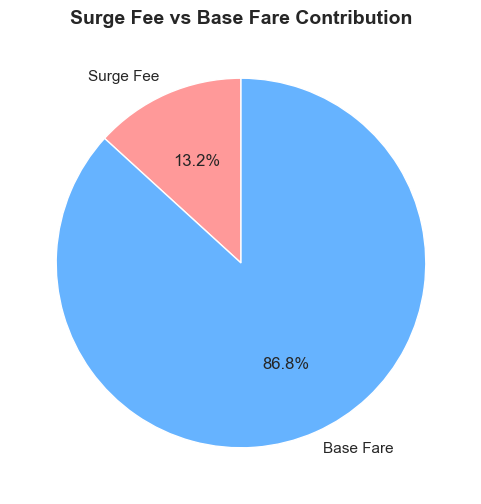

In [22]:
plt.figure(figsize=(6,6))
plt.pie([trips['surge_fee'].sum(), trips['fare_amount'].sum()],
        labels=['Surge Fee','Base Fare'],
        autopct='%1.1f%%',
        colors=['#ff9999','#66b3ff'],
        startangle=90)
plt.title("Surge Fee vs Base Fare Contribution", fontsize=14, fontweight='bold')
plt.show()

# Trips per Day

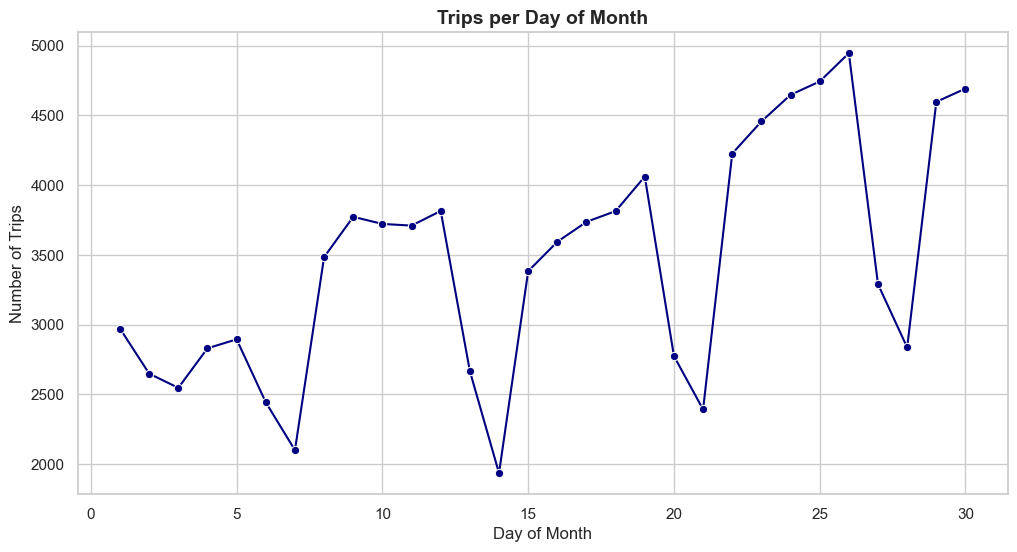

In [23]:
plt.figure(figsize=(12,6))
trips_per_day = trips.groupby('day')['trip_id'].count()
sns.lineplot(x=trips_per_day.index, y=trips_per_day.values, marker="o", color="navy")
plt.title("Trips per Day of Month", fontsize=14, fontweight='bold')
plt.xlabel("Day of Month")
plt.ylabel("Number of Trips")
plt.grid(True)
plt.show()

# Revenue Trend by Hour

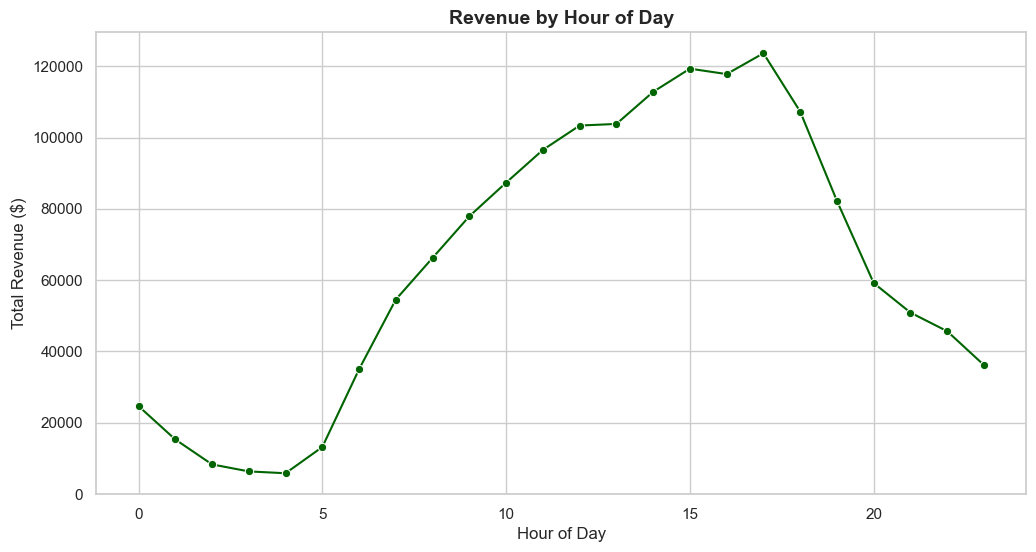

In [24]:
plt.figure(figsize=(12,6))
revenue_by_hour = trips.groupby('hour')['total_fare'].sum()
sns.lineplot(x=revenue_by_hour.index, y=revenue_by_hour.values, marker="o", color="darkgreen")
plt.title("Revenue by Hour of Day", fontsize=14, fontweight='bold')
plt.xlabel("Hour of Day")
plt.ylabel("Total Revenue ($)")
plt.grid(True)
plt.show()

# Passenger Count Distribution

C:\Users\User\AppData\Local\Temp\ipykernel_436\3565566142.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='passenger_count', data=trips, palette="coolwarm")


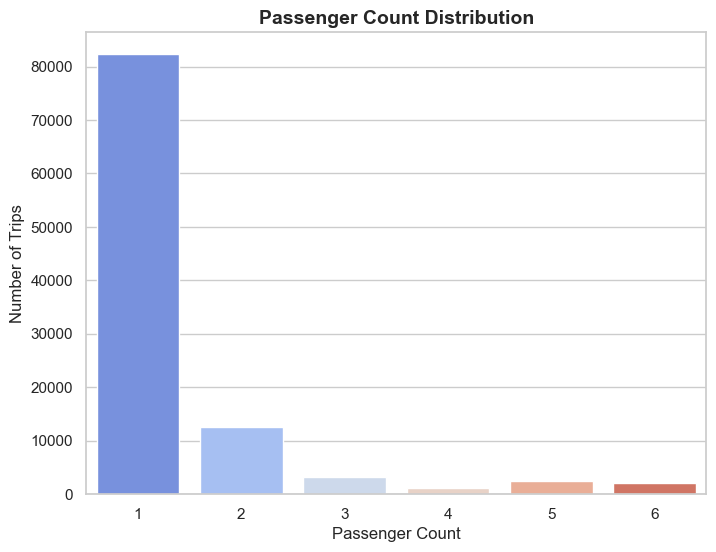

In [25]:
plt.figure(figsize=(8,6))
sns.countplot(x='passenger_count', data=trips, palette="coolwarm")
plt.title("Passenger Count Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Passenger Count")
plt.ylabel("Number of Trips")
plt.show()

# Trip Distance Distribution

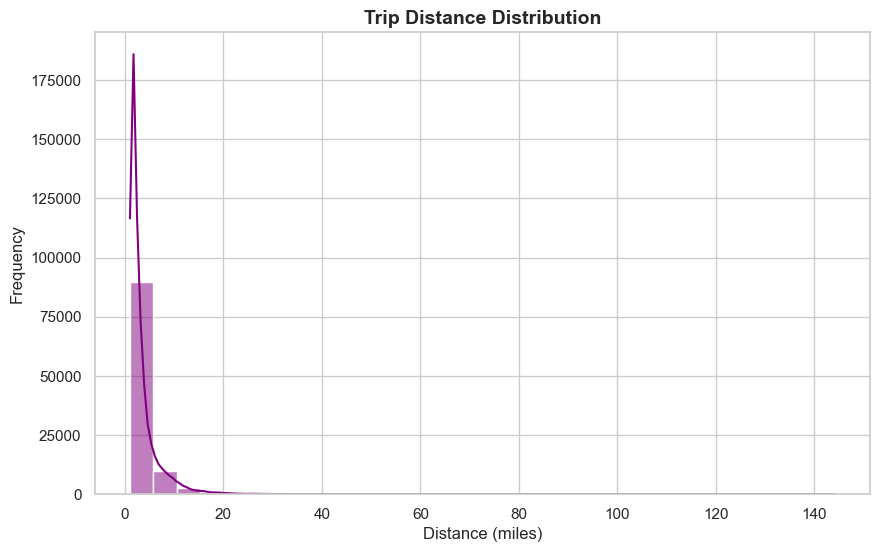

In [26]:
plt.figure(figsize=(10,6))
sns.histplot(trips['trip_distance'], bins=30, kde=True, color="purple")
plt.title("Trip Distance Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Distance (miles)")
plt.ylabel("Frequency")
plt.show()

# Fare vs Distance Scatter

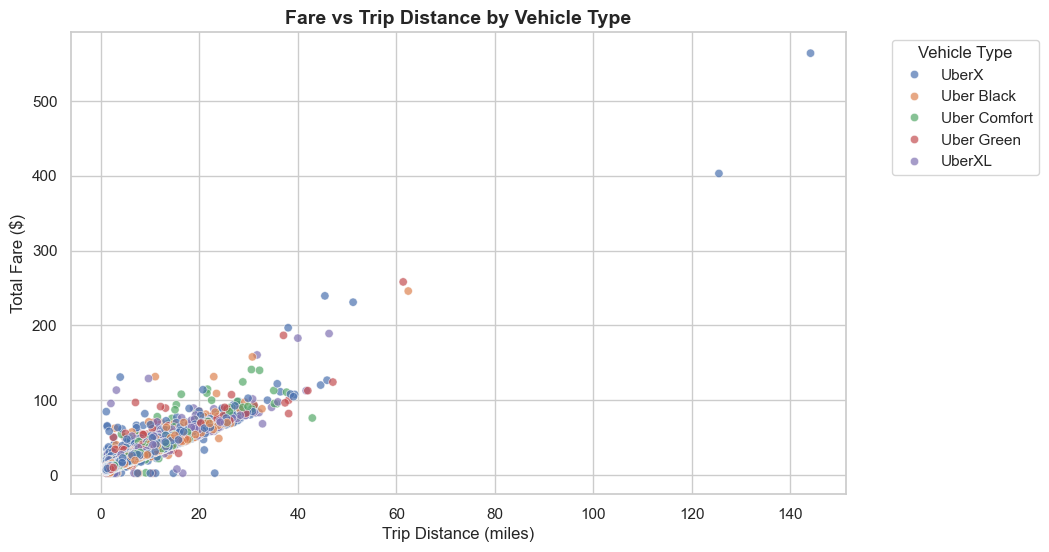

In [27]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='trip_distance', y='total_fare', data=trips, hue='vehicle', alpha=0.7)
plt.title("Fare vs Trip Distance by Vehicle Type", fontsize=14, fontweight='bold')
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Total Fare ($)")
plt.legend(title="Vehicle Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Top 10 Pickup Locations

C:\Users\User\AppData\Local\Temp\ipykernel_436\187316281.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_pickups.index, y=top_pickups.values, palette="crest")


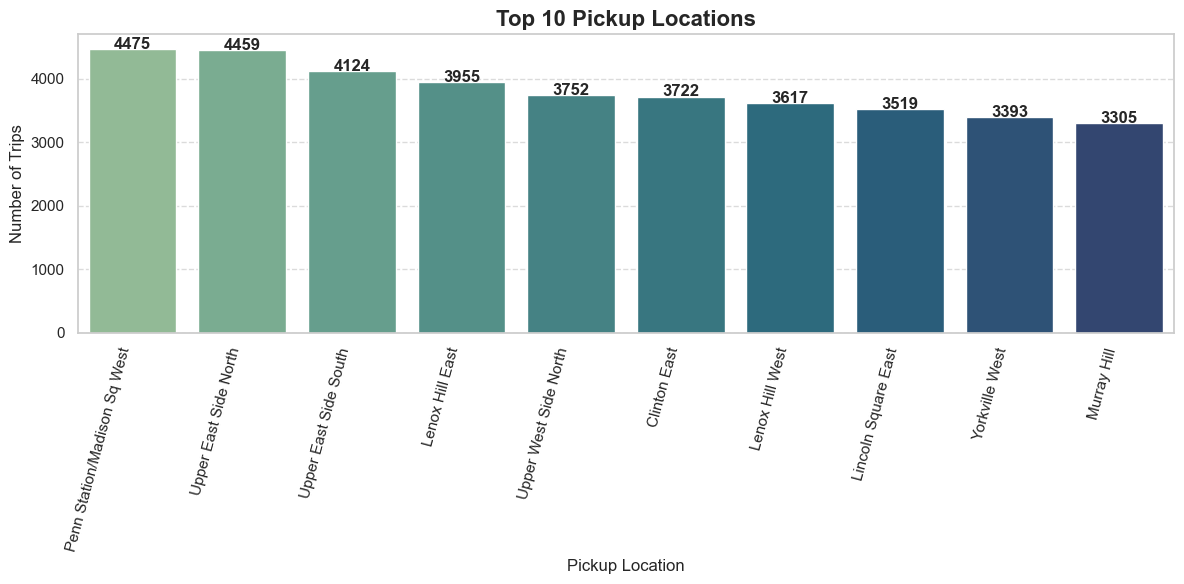

In [30]:
plt.figure(figsize=(12,6))

top_pickups = trips['location'].value_counts().head(10)

sns.barplot(x=top_pickups.index, y=top_pickups.values, palette="crest")

plt.title("Top 10 Pickup Locations", fontsize=16, fontweight='bold')
plt.xlabel("Pickup Location", fontsize=12)
plt.ylabel("Number of Trips", fontsize=12)
plt.xticks(rotation=75, ha="right")
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, v in enumerate(top_pickups.values):
    plt.text(i, v + 0.5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Top 10 Dropoff Locations

C:\Users\User\AppData\Local\Temp\ipykernel_436\2840604226.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_dropoffs.index, y=top_dropoffs.values, palette="mako")


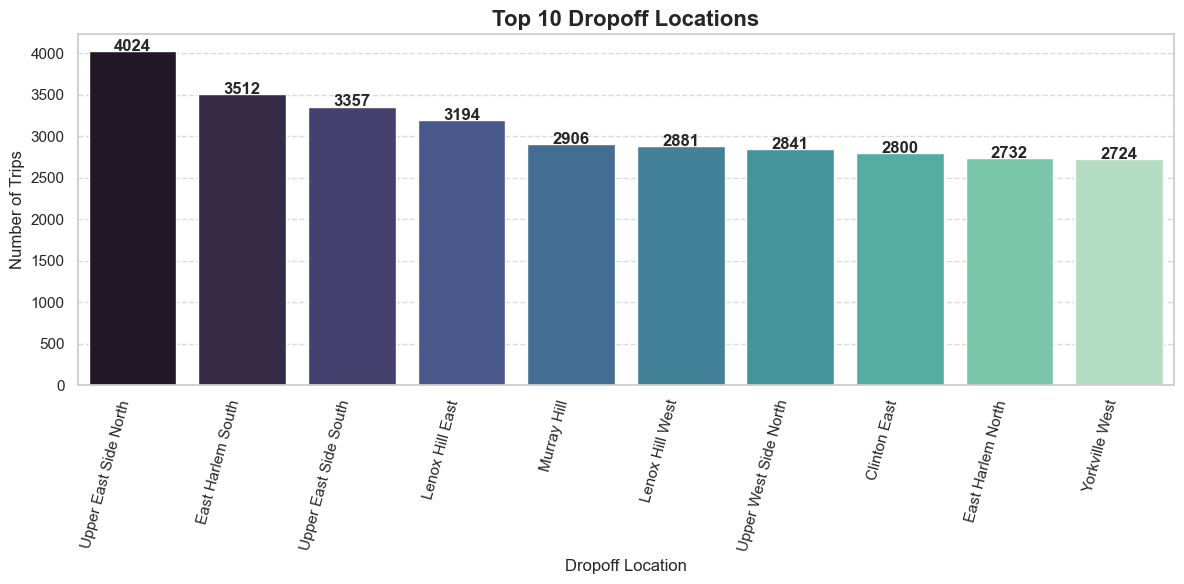

In [31]:
plt.figure(figsize=(12,6))

top_dropoffs = trips['location_dropoff'].value_counts().head(10)

sns.barplot(x=top_dropoffs.index, y=top_dropoffs.values, palette="mako")

plt.title("Top 10 Dropoff Locations", fontsize=16, fontweight='bold')
plt.xlabel("Dropoff Location", fontsize=12)
plt.ylabel("Number of Trips", fontsize=12)
plt.xticks(rotation=75, ha="right")
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, v in enumerate(top_dropoffs.values):
    plt.text(i, v + 0.5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()